# 01 — Basic Retrieval Augmented Generation (RAG)

**Project:** CIAL Knowledge OS — local, offline-first enterprise knowledge management for Cochin International Airport Ltd.  
**Notebook purpose:** establish the production foundation for every future retrieval pipeline.

> This notebook is intentionally written like an engineering chapter: every concept is explained, every implementation decision is explicit, and all components are replaceable through small abstractions.

## Offline guarantee

Before using any component, we ask: **Can this run completely offline?**

This notebook uses only local/open-source components:

| Layer | Component | Offline? | Replaceable? |
|---|---:|---:|---:|
| Documents | Local text files in `data/raw/` | Yes | Yes |
| Loading | LangChain community loaders | Yes | Yes |
| Chunking | `RecursiveCharacterTextSplitter` | Yes | Yes |
| Embeddings | `BAAI/bge-m3` via Sentence Transformers | Yes, when model is cached locally | Yes |
| Vector DB | Local Qdrant embedded storage | Yes | Yes |
| LLM | Ollama local model such as `qwen3` | Yes, when model is pulled locally | Yes |
| Plots | Matplotlib | Yes | Yes |

No OpenAI, Claude, Gemini, cloud inference, cloud vector DB, cloud OCR, or SaaS dependency is used.


## 1. Objective

Retrieval Augmented Generation (RAG) is an architecture that combines:

1. **Retrieval** — finding relevant enterprise knowledge from trusted sources.
2. **Augmentation** — placing only the most relevant source text into the model prompt.
3. **Generation** — asking a local language model to answer using that retrieved context.

### Why RAG exists

Vanilla LLMs are powerful language predictors, but they are not enterprise knowledge systems. They can fail because:

- Their training data may be outdated.
- They do not automatically know private airport SOPs, manuals, or policies.
- They may hallucinate plausible but unsupported answers.
- They cannot cite internal documents unless those documents are provided.
- Their context windows are finite and cannot hold every enterprise document.

### Why enterprises need RAG

Enterprises need answers that are:

- **Grounded** in approved documents.
- **Auditable** through metadata and source references.
- **Fresh** when manuals, SOPs, and policies change.
- **Secure** inside on-premises or air-gapped environments.
- **Modular** so models, vector databases, and parsers can be upgraded independently.

### Why CIAL requires RAG

Cochin International Airport Ltd. operates safety-critical, compliance-heavy processes: runway inspections, emergency response, electrical maintenance, fire safety, terminal operations, HVAC, and security. A knowledge assistant must answer from controlled documents rather than generic internet knowledge.

In CIAL Knowledge OS, this notebook is the first reusable building block for future production pipelines.


## 2. Theory

### LLMs

A Large Language Model (LLM) predicts text from a prompt. It can reason over provided context, but it does not inherently know private CIAL documents unless they are included in the prompt or encoded through another system.

### Context windows

The context window is the maximum text an LLM can process at one time. Enterprise document collections are much larger than a context window, so we retrieve only the smallest useful subset.

### Embeddings and vector spaces

An embedding model converts text into a numeric vector. Semantically similar text tends to have nearby vectors.

```mermaid
flowchart LR
    A["Runway inspection every 6 hours"] --> B[Embedding Model]
    C["How often is runway inspected?"] --> B
    B --> D[Nearby vectors in semantic space]
```

### Semantic search

Semantic search compares meaning rather than exact keywords. A query about "PPE for electrical work" can retrieve a manual section containing "arc-rated clothing" even if the words differ.

### Chunks and chunk overlap

Documents are split into chunks because embedding entire manuals loses detail and may exceed model limits. Overlap preserves context across boundaries.

Tradeoff:

- Smaller chunks: precise retrieval, but risk missing surrounding context.
- Larger chunks: more context, but more tokens and less focused retrieval.
- More overlap: fewer boundary errors, but more storage and duplicate retrieval.

### Document loaders

Loaders convert files into `Document` objects with text and metadata. Metadata is essential for auditability.

### Vector databases

A vector database stores embeddings and payload metadata, then returns nearest vectors for a query.

### Similarity search

Similarity search ranks chunks by distance or score. Higher score usually means stronger semantic match, depending on the distance metric.

### Prompt construction

The prompt should include only retrieved context, the question, and strict answer rules. This reduces token use and hallucination risk.

### Retriever and generator

- **Retriever:** finds the evidence.
- **Generator:** writes the final response from the evidence.

### Hallucination and grounding

Hallucination is unsupported generated content. Grounding reduces hallucination by requiring the model to use retrieved source text only.

### End-to-end RAG pipeline

```mermaid
flowchart TD
    U[User Question] --> QE[Embed Query]
    D[Documents] --> L[Load]
    L --> C[Chunk]
    C --> E[Embed Chunks]
    E --> V[(Vector Database)]
    QE --> V
    V --> R[Retrieved Context]
    R --> P[Grounded Prompt]
    U --> P
    P --> G[Local LLM]
    G --> A[Answer + Sources]
```


## 3. Architecture

```mermaid
flowchart TD
    PDF["Local Documents\nTXT/PDF/Manuals"] --> Loader["LangChain Loader"]
    Loader --> Chunker["Recursive Chunker"]
    Chunker --> Embedding["BAAI/bge-m3\nSentence Transformers"]
    Embedding --> Qdrant[("Local Qdrant\nPersistent Store")]
    Query["User Question"] --> QueryEmbedding["Query Embedding"]
    QueryEmbedding --> Qdrant
    Qdrant --> Retriever["Top-k Retriever"]
    Retriever --> Prompt["Grounded Prompt\nMinimal Context"]
    Prompt --> LLM["Ollama Local LLM\nqwen3"]
    LLM --> Answer["Answer with Sources"]
```

Every stage is isolated so CIAL can replace models, storage, loaders, or generation without rewriting the whole platform.


## 4. Implementation

The following cells build a complete local RAG pipeline from document creation through answer generation.


### Imports


In [1]:
import sys
print(sys.executable)

e:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\.venv\Scripts\python.exe


In [2]:
from __future__ import annotations

import os
import shutil
import subprocess
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaLLM
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams
from sentence_transformers import SentenceTransformer
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Offline-first defaults. Models must already exist in the local cache / Ollama store.
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")


C:\Users\Adithya A\AppData\Local\Temp\ipykernel_78812\2607419475.py:21: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, TextLoader


'1'

### Configuration

All paths and model names live in one configuration object. No pipeline function depends on hardcoded paths.


In [3]:
@dataclass(frozen=True)
class RAGConfig:
    project_root: Path = field(default_factory=lambda: Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve())
    raw_data_dir: Path = field(init=False)
    qdrant_dir: Path = field(init=False)
    collection_name: str = "cial_basic_rag_bge_m3"
    embedding_model_name: str = "BAAI/bge-m3"
    llm_model_name: str = "deepseek-r1:14b"
    chunk_size: int = 700
    chunk_overlap: int = 120
    retrieval_top_k: int = 3
    random_seed: int = 42

    def __post_init__(self) -> None:
        object.__setattr__(self, "raw_data_dir", self.project_root / "data" / "raw")
        object.__setattr__(self, "qdrant_dir", self.project_root / "data" / "qdrant" / self.collection_name)

config = RAGConfig()
np.random.seed(config.random_seed)
print(config)


RAGConfig(project_root=WindowsPath('E:/Adithya A/CIAL-Project/CIAL-Knowledge-OS'), raw_data_dir=WindowsPath('E:/Adithya A/CIAL-Project/CIAL-Knowledge-OS/data/raw'), qdrant_dir=WindowsPath('E:/Adithya A/CIAL-Project/CIAL-Knowledge-OS/data/qdrant/cial_basic_rag_bge_m3'), collection_name='cial_basic_rag_bge_m3', embedding_model_name='BAAI/bge-m3', llm_model_name='deepseek-r1:14b', chunk_size=700, chunk_overlap=120, retrieval_top_k=3, random_seed=42)


### Utilities


In [4]:
def timed(label: str, metrics: dict[str, float]):
    """Small context manager for reproducible timing metrics."""
    class Timer:
        def __enter__(self):
            self.start = time.perf_counter()
            return self
        def __exit__(self, exc_type, exc, tb):
            metrics[label] = time.perf_counter() - self.start
    return Timer()


def get_gpu_snapshot() -> dict[str, Any]:
    """Return lightweight GPU information without requiring cloud services."""
    info: dict[str, Any] = {"cuda_available": torch.cuda.is_available()}
    if torch.cuda.is_available():
        info["torch_device"] = torch.cuda.get_device_name(0)
        info["allocated_gb"] = round(torch.cuda.memory_allocated(0) / 1024**3, 3)
    nvidia_smi = shutil.which("nvidia-smi")
    if nvidia_smi:
        result = subprocess.run(
            [nvidia_smi, "--query-gpu=utilization.gpu,memory.used,memory.total", "--format=csv,noheader,nounits"],
            capture_output=True,
            text=True,
            check=False,
        )
        if result.returncode == 0 and result.stdout.strip():
            util, mem_used, mem_total = result.stdout.strip().splitlines()[0].split(", ")
            info.update({"gpu_utilization_pct": float(util), "gpu_memory_used_mb": float(mem_used), "gpu_memory_total_mb": float(mem_total)})
    return info


def print_documents_summary(documents: list[Document]) -> None:
    print(f"Documents: {len(documents)}")
    for doc in documents[:3]:
        print({"source": doc.metadata.get("source"), "chars": len(doc.page_content)})


### Create Sample Documents

These documents are synthetic but realistic airport knowledge artifacts. They are stored in `data/raw/` so the loader path mirrors a production ingestion folder.


In [5]:
SAMPLE_DOCUMENTS: dict[str, str] = {
    "cial_sop_terminal_operations.txt": """
CIAL Terminal Operations SOP
Version: 1.0
Owner: Airport Operations Control Centre

Passenger queue monitoring must be reviewed every 15 minutes during peak periods. Duty managers shall coordinate with airline supervisors when queue length exceeds the marked holding area. Public announcements must be clear, multilingual where required, and approved by terminal control.

Escalators, elevators, baggage belts, and passenger boarding bridges must be visually checked at the start of each shift. Any unsafe condition must be isolated and reported to engineering control before passenger use resumes.
""",
    "cial_fire_safety_manual.txt": """
CIAL Fire Safety Manual
Version: 1.0
Owner: Airport Rescue and Fire Fighting Service

Hot work requires a valid permit, a trained fire watch, and a dry chemical extinguisher within 10 metres. The fire watch shall remain in the area for at least 30 minutes after work completion.

Fuel spill response requires immediate ignition source control, area cordoning, notification to ARFF control, and use of approved absorbent material. Personnel must avoid walking through contaminated areas.
""",
    "cial_runway_maintenance_sop.txt": """
CIAL Runway Maintenance SOP
Version: 1.0
Owner: Airside Operations

Routine runway surface inspection shall be performed every 6 hours and additionally after heavy rain, bird strike reports, foreign object debris alerts, or pilot braking-action complaints. Findings must be logged with time, inspector name, location, and corrective action.

Before entering the runway strip, maintenance teams must obtain explicit clearance from ATC and maintain continuous radio contact. Vehicles shall use amber beacons and follow approved access routes.
""",
    "cial_electrical_maintenance_manual.txt": """
CIAL Electrical Maintenance Manual
Version: 1.0
Owner: Electrical Engineering

Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric safety shoes, insulated tools, and lockout-tagout verification wherever isolation is possible.

Emergency shutdown shall be performed by pressing the designated emergency stop, opening the upstream breaker when safe, notifying electrical control, applying lockout-tagout, and recording the event in the maintenance log.
""",
    "cial_hvac_operations_manual.txt": """
CIAL HVAC Operations Manual
Version: 1.0
Owner: Mechanical Engineering

Air handling units serving passenger areas must be inspected daily for abnormal vibration, condensate leakage, filter differential pressure, and supply temperature. Filters should be replaced when pressure drop exceeds the approved threshold or during scheduled preventive maintenance.

Critical terminal zones must maintain temperature and ventilation targets defined by facility operations. Any sustained deviation longer than 20 minutes must be escalated to mechanical control.
""",
    "cial_security_policy.txt": """
CIAL Security Policy
Version: 1.0
Owner: Aviation Security Group

Restricted area access requires a valid airport entry permit, identity verification, and role-based authorization. Tailgating is prohibited. Security staff must challenge unidentified persons and report access violations immediately.

Security incident records must include date, time, location, persons involved, action taken, and escalation reference. Records are retained according to the approved compliance schedule.
""",
    "cial_emergency_response_plan.txt": """
CIAL Emergency Response Plan
Version: 1.0
Owner: Emergency Planning Cell

For aircraft emergencies, the emergency operations centre shall be activated, ARFF shall proceed according to category response procedures, medical teams shall be placed on standby, and terminal operations shall prepare passenger information support.

Emergency communication must use clear terminology, avoid speculation, and identify the command role of the speaker. Situation updates must be timestamped and logged.
""",
}


def create_sample_documents(raw_dir: Path, documents: dict[str, str]) -> list[Path]:
    raw_dir.mkdir(parents=True, exist_ok=True)
    written: list[Path] = []
    for filename, content in documents.items():
        path = raw_dir / filename
        path.write_text(content.strip() + "\n", encoding="utf-8")
        written.append(path)
    return written

written_paths = create_sample_documents(config.raw_data_dir, SAMPLE_DOCUMENTS)
print(f"Wrote {len(written_paths)} documents to {config.raw_data_dir}")
for path in written_paths:
    print("-", path.name)


Wrote 7 documents to E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\raw
- cial_sop_terminal_operations.txt
- cial_fire_safety_manual.txt
- cial_runway_maintenance_sop.txt
- cial_electrical_maintenance_manual.txt
- cial_hvac_operations_manual.txt
- cial_security_policy.txt
- cial_emergency_response_plan.txt


### Load Documents

`DirectoryLoader` and `TextLoader` run locally and preserve source metadata for downstream audit trails.


In [6]:
def load_documents(raw_dir: Path) -> list[Document]:
    loader = DirectoryLoader(
        str(raw_dir),
        glob="*.txt",
        loader_cls=TextLoader,
        loader_kwargs={"encoding": "utf-8"},
        show_progress=False,
    )
    return loader.load()

documents = load_documents(config.raw_data_dir)
print_documents_summary(documents)


Documents: 7
{'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\raw\\cial_electrical_maintenance_manual.txt', 'chars': 557}
{'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\raw\\cial_emergency_response_plan.txt', 'chars': 493}
{'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\raw\\cial_fire_safety_manual.txt', 'chars': 487}


### Chunk Documents

We experiment with multiple chunk settings before selecting the production default. The chosen default balances retrieval precision against enough surrounding procedure context.


In [7]:
def chunk_documents(documents: list[Document], chunk_size: int, chunk_overlap: int) -> list[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
        add_start_index=True,
    )
    chunks = splitter.split_documents(documents)
    for idx, chunk in enumerate(chunks):
        chunk.metadata["chunk_id"] = idx
        chunk.metadata["chunk_size"] = len(chunk.page_content)
    return chunks

experiment_settings = [(350, 60), (700, 120), (1100, 180)]
chunk_experiments = {setting: chunk_documents(documents, *setting) for setting in experiment_settings}
for (size, overlap), chunks_for_setting in chunk_experiments.items():
    lengths = [len(c.page_content) for c in chunks_for_setting]
    print({"chunk_size": size, "overlap": overlap, "num_chunks": len(chunks_for_setting), "avg_chars": round(float(np.mean(lengths)), 1)})

chunks = chunk_experiments[(config.chunk_size, config.chunk_overlap)]
print(f"Selected {len(chunks)} chunks for indexing")


{'chunk_size': 350, 'overlap': 60, 'num_chunks': 16, 'avg_chars': 230.8}
{'chunk_size': 700, 'overlap': 120, 'num_chunks': 7, 'avg_chars': 530.1}
{'chunk_size': 1100, 'overlap': 180, 'num_chunks': 7, 'avg_chars': 530.1}
Selected 7 chunks for indexing


### Embeddings

`BAAI/bge-m3` is a strong open-source embedding model. The notebook loads it through Sentence Transformers and uses CUDA when available.


In [8]:
metrics: dict[str, float] = {}
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding device:", device)
print("GPU snapshot before loading:", get_gpu_snapshot())

with timed("embedding_model_load_seconds", metrics):
    embedding_model = SentenceTransformer(config.embedding_model_name, device=device, local_files_only=True)

sample_vector = embedding_model.encode(["CIAL runway inspection interval"], normalize_embeddings=True)[0]
embedding_dim = int(sample_vector.shape[0])
print("Embedding dimensions:", embedding_dim)
print("GPU snapshot after loading:", get_gpu_snapshot())

with timed("embedding_seconds", metrics):
    chunk_texts = [chunk.page_content for chunk in chunks]
    chunk_vectors = embedding_model.encode(chunk_texts, batch_size=8, normalize_embeddings=True, show_progress_bar=False)
print(f"Embedded {len(chunk_vectors)} chunks in {metrics['embedding_seconds']:.3f}s")


Embedding device: cuda
GPU snapshot before loading: {'cuda_available': True, 'torch_device': 'NVIDIA GeForce RTX 5070 Ti Laptop GPU', 'allocated_gb': 0.0, 'gpu_utilization_pct': 0.0, 'gpu_memory_used_mb': 0.0, 'gpu_memory_total_mb': 12227.0}


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding dimensions: 1024
GPU snapshot after loading: {'cuda_available': True, 'torch_device': 'NVIDIA GeForce RTX 5070 Ti Laptop GPU', 'allocated_gb': 2.146, 'gpu_utilization_pct': 6.0, 'gpu_memory_used_mb': 2470.0, 'gpu_memory_total_mb': 12227.0}
Embedded 7 chunks in 0.134s


### Vector Database

Qdrant stores vectors plus payload metadata. Payload fields let production systems filter by document type, department, version, ACL, or retention policy.


In [9]:
def build_qdrant_index(config: RAGConfig, chunks: list[Document], vectors: np.ndarray, vector_size: int) -> QdrantClient:
    config.qdrant_dir.mkdir(parents=True, exist_ok=True)
    client = QdrantClient(path=str(config.qdrant_dir))
    if client.collection_exists(config.collection_name):
        client.delete_collection(config.collection_name)
    client.create_collection(
        collection_name=config.collection_name,
        vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE),
    )
    points: list[PointStruct] = []
    for idx, (chunk, vector) in enumerate(zip(chunks, vectors)):
        payload = {
            "text": chunk.page_content,
            "source": str(chunk.metadata.get("source", "")),
            "chunk_id": int(chunk.metadata["chunk_id"]),
            "start_index": int(chunk.metadata.get("start_index", -1)),
            "chunk_size": int(chunk.metadata["chunk_size"]),
        }
        points.append(PointStruct(id=idx, vector=vector.tolist(), payload=payload))
    client.upsert(collection_name=config.collection_name, points=points)
    return client

with timed("indexing_seconds", metrics):
    qdrant = build_qdrant_index(config, chunks, chunk_vectors, embedding_dim)
print(qdrant.get_collection(config.collection_name))
print(f"Indexing time: {metrics['indexing_seconds']:.3f}s")


status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=0 points_count=7 segments_count=1 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=1024, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=None, sharding_method=None, replication_factor=None, write_consistency_factor=None, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_optimization_threads=1, prevent_unoptimized=None), wal_config=Wal

### Retrieval

The retriever embeds a question, searches Qdrant, and returns the highest-scoring chunks with metadata.


In [10]:
def retrieve(query: str, top_k: int = config.retrieval_top_k) -> list[Any]:
    query_vector = embedding_model.encode([query], normalize_embeddings=True)[0]
    response = qdrant.query_points(
        collection_name=config.collection_name,
        query=query_vector.tolist(),
        limit=top_k,
        with_payload=True,
    )
    return response.points

query = "What PPE is required for electrical maintenance?"
with timed("retrieval_seconds", metrics):
    results = retrieve(query)

for rank, result in enumerate(results, start=1):
    print(f"\nRank {rank} | score={result.score:.4f}")
    print("Metadata:", {k: v for k, v in result.payload.items() if k != "text"})
    print(result.payload["text"][:500])



Rank 1 | score=0.6341
Metadata: {'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\raw\\cial_electrical_maintenance_manual.txt', 'chunk_id': 0, 'start_index': 0, 'chunk_size': 556}
CIAL Electrical Maintenance Manual
Version: 1.0
Owner: Electrical Engineering

Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric safety shoes, insulated tools, and lockout-tagout verification wherever isolation is possible.

Emergency shutdown shall be performed by pressing the designated emergency stop, opening the upstream breaker when safe, notifying electrical control, applying lockout

Rank 2 | score=0.4785
Metadata: {'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\raw\\cial_hvac_operations_manual.txt', 'chunk_id': 3, 'start_index': 0, 'chunk_size': 552}
CIAL HVAC Operations Manual
Version: 1.0
Owner: Mechanical Engineering

Air handling units serving passenger are

### Local LLM and Grounded Prompt

The prompt is intentionally compact: only top-k context is sent to the LLM. This saves tokens, reduces latency, and limits opportunities for unsupported answers.


In [11]:
def format_context(results: list[Any], max_chars_per_chunk: int = 900) -> str:
    blocks: list[str] = []
    for idx, result in enumerate(results, start=1):
        payload = result.payload
        source = Path(payload["source"]).name
        text = payload["text"][:max_chars_per_chunk]
        blocks.append(f"[Source {idx}: {source} | chunk {payload['chunk_id']} | score {result.score:.3f}]\n{text}")
    return "\n\n".join(blocks)


def build_grounded_prompt(question: str, retrieved_results: list[Any]) -> str:
    context = format_context(retrieved_results)
    return f"""You are CIAL Knowledge OS, an on-prem airport knowledge assistant.
Answer the question using ONLY the retrieved context below.
If the context does not contain the answer, say: "I do not know based on the retrieved CIAL documents."
Keep the answer concise and include source names.

Retrieved context:
{context}

Question: {question}
Answer:"""

llm = OllamaLLM(model=config.llm_model_name, temperature=0)
print("Configured local Ollama model:", config.llm_model_name)


Configured local Ollama model: deepseek-r1:14b


### Ask Questions


In [12]:
def answer_question(question: str, show_prompt: bool = True) -> dict[str, Any]:
    start_total = time.perf_counter()
    start_retrieval = time.perf_counter()
    retrieved = retrieve(question)
    retrieval_latency = time.perf_counter() - start_retrieval
    prompt = build_grounded_prompt(question, retrieved)
    start_generation = time.perf_counter()
    answer = llm.invoke(prompt)
    generation_latency = time.perf_counter() - start_generation
    total_latency = time.perf_counter() - start_total
    if show_prompt:
        print("=" * 100)
        print("QUESTION:", question)
        print("\nRETRIEVED CONTEXT:\n", format_context(retrieved))
        print("\nPROMPT:\n", prompt)
        print("\nANSWER:\n", answer)
    return {
        "question": question,
        "retrieved": retrieved,
        "prompt": prompt,
        "answer": answer,
        "retrieval_latency": retrieval_latency,
        "generation_latency": generation_latency,
        "total_latency": total_latency,
    }

questions = [
    "What PPE is required for electrical maintenance?",
    "What is the runway inspection interval?",
    "How should an emergency shutdown be performed?",
]

qa_runs = [answer_question(q, show_prompt=True) for q in questions]
metrics["generation_seconds_total"] = sum(run["generation_latency"] for run in qa_runs)
metrics["total_pipeline_seconds_avg"] = float(np.mean([run["total_latency"] for run in qa_runs]))


QUESTION: What PPE is required for electrical maintenance?

RETRIEVED CONTEXT:
 [Source 1: cial_electrical_maintenance_manual.txt | chunk 0 | score 0.634]
CIAL Electrical Maintenance Manual
Version: 1.0
Owner: Electrical Engineering

Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric safety shoes, insulated tools, and lockout-tagout verification wherever isolation is possible.

Emergency shutdown shall be performed by pressing the designated emergency stop, opening the upstream breaker when safe, notifying electrical control, applying lockout-tagout, and recording the event in the maintenance log.

[Source 2: cial_hvac_operations_manual.txt | chunk 3 | score 0.479]
CIAL HVAC Operations Manual
Version: 1.0
Owner: Mechanical Engineering

Air handling units serving passenger areas must be inspected daily for abnormal vibration, condensate leakage, filter differential pressure, and su

## 5. Visualization

Matplotlib is used because it is local, lightweight, and sufficient for engineering diagnostics.


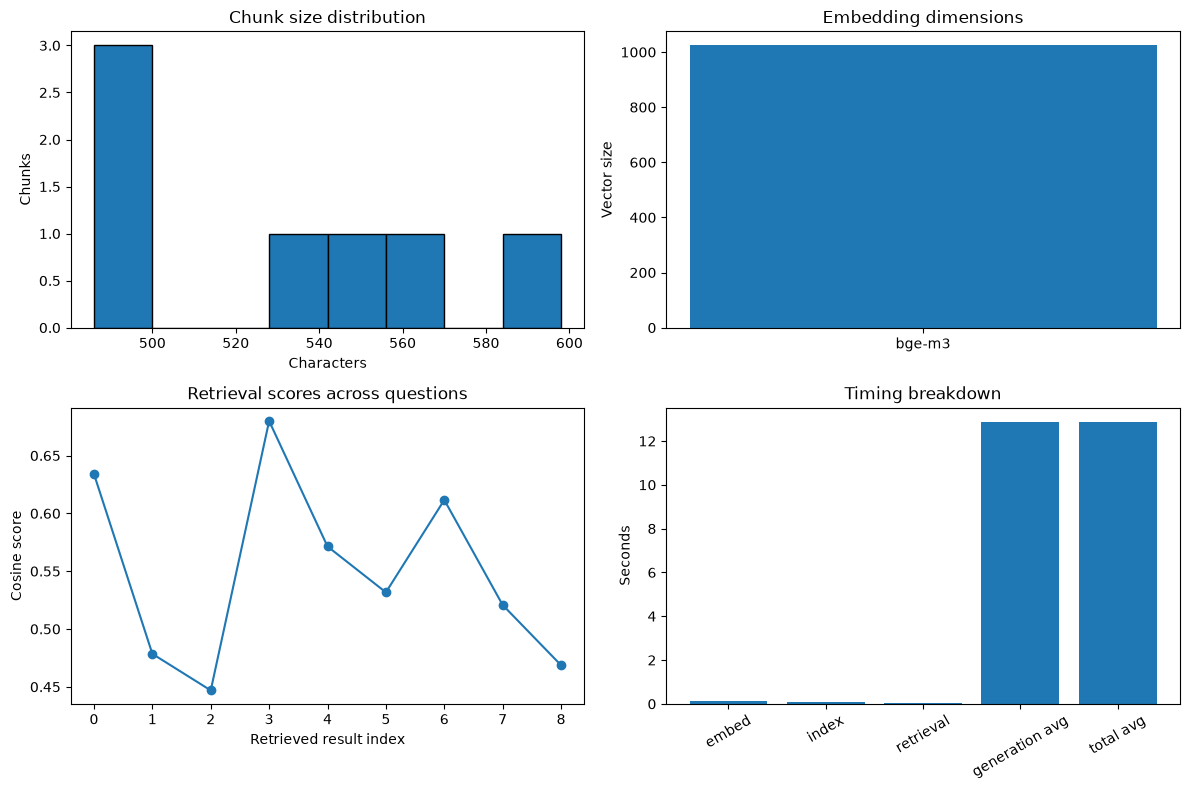

In [13]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]
retrieval_scores = [result.score for run in qa_runs for result in run["retrieved"]]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(chunk_lengths, bins=8, edgecolor="black")
axes[0, 0].set_title("Chunk size distribution")
axes[0, 0].set_xlabel("Characters")
axes[0, 0].set_ylabel("Chunks")

axes[0, 1].bar(["bge-m3"], [embedding_dim])
axes[0, 1].set_title("Embedding dimensions")
axes[0, 1].set_ylabel("Vector size")

axes[1, 0].plot(retrieval_scores, marker="o")
axes[1, 0].set_title("Retrieval scores across questions")
axes[1, 0].set_xlabel("Retrieved result index")
axes[1, 0].set_ylabel("Cosine score")

latency_labels = ["embed", "index", "retrieval", "generation avg", "total avg"]
latency_values = [
    metrics.get("embedding_seconds", 0),
    metrics.get("indexing_seconds", 0),
    metrics.get("retrieval_seconds", 0),
    float(np.mean([run["generation_latency"] for run in qa_runs])),
    metrics.get("total_pipeline_seconds_avg", 0),
]
axes[1, 1].bar(latency_labels, latency_values)
axes[1, 1].set_title("Timing breakdown")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()


## 6. Benchmark

The benchmark captures core latency points. GPU utilization is best-effort because not every environment exposes `nvidia-smi`.


In [14]:
benchmark = {
    "embedding_model_load_seconds": metrics.get("embedding_model_load_seconds"),
    "embedding_time_seconds": metrics.get("embedding_seconds"),
    "indexing_time_seconds": metrics.get("indexing_seconds"),
    "retrieval_latency_seconds_last_single_query": metrics.get("retrieval_seconds"),
    "generation_latency_seconds_avg": float(np.mean([run["generation_latency"] for run in qa_runs])),
    "total_pipeline_latency_seconds_avg": metrics.get("total_pipeline_seconds_avg"),
    "gpu_snapshot": get_gpu_snapshot(),
}
benchmark


{'embedding_model_load_seconds': 4.752627600013511,
 'embedding_time_seconds': 0.13444120000349358,
 'indexing_time_seconds': 0.07537430000957102,
 'retrieval_latency_seconds_last_single_query': 0.02675630000885576,
 'generation_latency_seconds_avg': 12.869266166662177,
 'total_pipeline_latency_seconds_avg': 12.885130533347061,
 'gpu_snapshot': {'cuda_available': True,
  'torch_device': 'NVIDIA GeForce RTX 5070 Ti Laptop GPU',
  'allocated_gb': 2.146,
  'gpu_utilization_pct': 0.0,
  'gpu_memory_used_mb': 11745.0,
  'gpu_memory_total_mb': 12227.0}}

## 7. Advantages

- **Grounding:** Answers are based on retrieved CIAL documents rather than model memory.
- **Reduced hallucinations:** The prompt explicitly forbids unsupported claims.
- **Fresh knowledge:** Updating documents and re-indexing updates the system without fine-tuning.
- **Scalability:** Vector databases support growing document collections.
- **Enterprise suitability:** Metadata, source tracking, and local deployment align with operational governance.

## 8. Limitations

- **Chunking issues:** Bad boundaries can split a procedure from its condition or exception.
- **Embedding limitations:** Dense retrieval may miss exact codes, IDs, forms, or rare terminology.
- **Context window constraints:** Only top chunks fit into the prompt.
- **Retrieval errors:** If retrieval misses evidence, generation cannot recover reliably.
- **Latency:** Embedding, vector search, and local LLM generation add runtime.
- **No reranking:** This notebook does not include a cross-encoder or LLM reranker.
- **No hybrid search:** Sparse keyword search is not yet combined with dense search.

## 9. Enterprise Considerations for CIAL

CIAL Knowledge OS must support airport-grade governance:

- **Security:** Documents, embeddings, prompts, and answers remain on-premises.
- **Air-gapped environments:** Cached models and local Qdrant storage allow offline operation.
- **Model upgrades:** Embedding and LLM names are configuration values, not hardcoded pipeline logic.
- **Document versioning:** Payload metadata can be extended with version, owner, effective date, and approval status.
- **Access control:** Future retrievers can filter Qdrant payloads by department, role, or clearance.
- **Audit logs:** Query, retrieved chunk IDs, scores, prompt, answer, and latency can be stored for review.
- **Future multi-user deployment:** The same abstractions can move into an API backend with authentication and per-user authorization.

This notebook is therefore the first building block of Knowledge OS: it defines the ingestion, retrieval, grounding, and generation contract that later notebooks will improve.

## 10. What We'll Improve Next

Notebook 02 will improve query quality and retrieval robustness. Future notebooks will cover:

- Multi-query retrieval
- HyDE
- Query rewriting
- Reranking
- Hybrid dense + sparse search
- Metadata filtering
- Parent document retrieval
- Agentic retrieval
- Knowledge graphs
- Evaluation datasets and metrics

The key lesson from Notebook 01: **a production RAG system is not one model call; it is a controlled evidence pipeline.**
